# Delivery Demand Forecasting

This notebook compares forecasting models for daily delivery demand. Each model is trained on earlier dates and evaluated on the final 30 days.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

from statsmodels.tsa.arima.model import ARIMA 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor 
from prophet import Prophet 

Importing plotly failed. Interactive plots will not work.


## 2. Load and review the data

Load the cleaned daily dataset and review its first rows, structure, and summary statistics.

In [3]:
DATASET_PATH = "../dataset/cleaned_dataset.pkl"

In [4]:
dataset = pd.read_pickle(DATASET_PATH)

In [5]:
dataset.head()

,unfavorable_weather_count,extreme_temp_count,distance_km_mean,package_weight_kg_mean,delivery_cost_mean,expected_delivery_duration_hrs,delivery_count,day_of_week,is_weekend
delivery_date,,,,,,,,,
2025-01-01,84,47,129.805882,25.430588,758.846261,3.890850,153,2,0
2025-01-02,71,46,161.175540,25.813381,921.743754,4.792806,139,3,0
2025-01-03,68,49,153.478417,25.527842,884.255180,4.568345,139,4,0
2025-01-04,64,39,147.213821,24.980650,853.960613,4.401626,123,5,1
2025-01-05,63,53,161.870714,25.186929,921.749624,4.810714,140,6,1


In [6]:
dataset.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 181 entries, 2025-01-01 to 2025-06-30
Freq: D
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   unfavorable_weather_count       181 non-null    int64  
 1   extreme_temp_count              181 non-null    int64  
 2   distance_km_mean                181 non-null    float64
 3   package_weight_kg_mean          181 non-null    float64
 4   delivery_cost_mean              181 non-null    float64
 5   expected_delivery_duration_hrs  181 non-null    float64
 6   delivery_count                  181 non-null    int64  
 7   day_of_week                     181 non-null    int32  
 8   is_weekend                      181 non-null    int64  
dtypes: float64(4), int32(1), int64(4)
memory usage: 13.4 KB


In [7]:
dataset.describe()

,unfavorable_weather_count,extreme_temp_count,distance_km_mean,package_weight_kg_mean,delivery_cost_mean,expected_delivery_duration_hrs,delivery_count,day_of_week,is_weekend
count,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000
mean,69.546961,45.790055,150.367422,25.168753,864.881379,4.502829,138.121547,3.011050,0.287293
std,8.761929,6.740434,8.261918,1.206269,41.311151,0.238155,11.897088,2.005517,0.453755
min,47.000000,30.000000,129.805882,21.242238,758.846261,3.890850,107.000000,0.000000,0.000000
25%,64.000000,41.000000,145.415909,24.394872,837.215571,4.353846,130.000000,1.000000,0.000000
50%,69.000000,45.000000,149.574815,25.269060,861.184679,4.490411,138.000000,3.000000,0.000000
75%,76.000000,50.000000,155.847682,26.011409,890.313076,4.647200,147.000000,5.000000,1.000000
max,95.000000,69.000000,175.658333,28.278722,994.748474,5.231818,175.000000,6.000000,1.000000


## 3. Create training and test sets

Reserve the final 30 days for testing. Earlier observations are used for training so the evaluation follows the time order of the data.

In [9]:
split_date = dataset.index.max() - pd.Timedelta(days=30)
split_position = dataset.index.get_loc(split_date)

total_count = len(dataset.index)
split_pct = (split_position + 1) / total_count 

test_size = 1.0 - split_pct 

X = dataset.drop(columns="delivery_count")
y = dataset["delivery_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)

## 4. Baseline Forecasts

Simple reference forecasts: a naive forecast that repeats the latest observed value and a 7-day moving-average forecast.

In [11]:
# Naive Forecast
last_known_value = y_train.iloc[-1] 

naive_predictions = np.repeat(last_known_value, len(y_test)) 

In [12]:
# Evaluate the forecast.
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_predictions))
naive_mae = mean_absolute_error(y_test, naive_predictions)
naive_mape = np.mean(np.abs((y_test - naive_predictions) / y_test)) * 100
naive_mfe = np.mean(y_test - naive_predictions)

print(f"MAE:  {naive_mae:.2f}")
print(f"RMSE: {naive_rmse:.2f}")
print(f"MAPE: {naive_mape:.2f}%")
print(f"Bias (MFE): {naive_mfe:.2f}")

MAE:  10.71
RMSE: 13.50
MAPE: 8.04%
Bias (MFE): -0.52


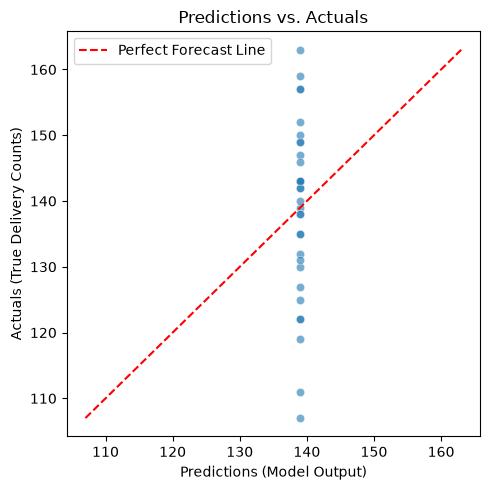

In [13]:
# Plot predictions against actual values.
plt.figure(figsize=(5, 5))

# Create the scatter plot.
sns.scatterplot(x=naive_predictions, y=y_test, alpha=0.6)

# Label the axes.
plt.xlabel("Predictions (Model Output)")
plt.ylabel("Actuals (True Delivery Counts)")
plt.title("Predictions vs. Actuals")

# Add a perfect-forecast reference line.

min_val = min(y_test.min(), naive_predictions.min())
max_val = max(y_test.max(), naive_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Forecast Line')

plt.legend()
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

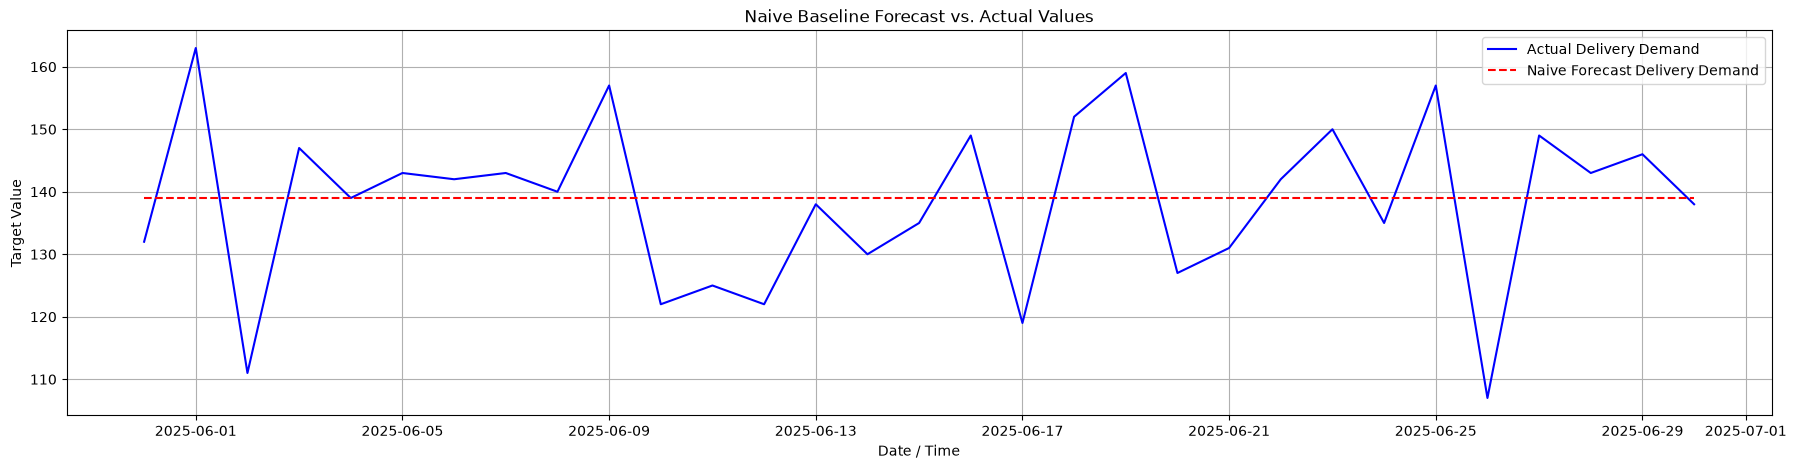

In [14]:
plt.figure(figsize=(22, 5))

# Plot actual and forecast values.
plt.plot(y_test.index, y_test, label='Actual Delivery Demand', color='blue')
plt.plot(y_test.index, naive_predictions, label='Naive Forecast Delivery Demand', color='red', linestyle='--')

# Add labels, a grid, and a legend.
plt.title('Naive Baseline Forecast vs. Actual Values')
plt.xlabel('Date / Time')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)

plt.show

In [15]:
# Moving Average Forecast

last_7_days = y_train.iloc[-7:]
moving_avg = last_7_days.mean()

ma_predictions = np.repeat(moving_avg, len(y_test)) 

In [16]:
# Evaluate the forecast.
ma_rmse = np.sqrt(mean_squared_error(y_test, ma_predictions))
ma_mae = mean_absolute_error(y_test, ma_predictions)
ma_mape = np.mean(np.abs((y_test - ma_predictions) / y_test)) * 100
ma_mfe = np.mean(y_test - ma_predictions)

print(f"MAE:  {ma_mae:.2f}")
print(f"RMSE: {ma_rmse:.2f}")
print(f"MAPE: {ma_mape:.2f}%")
print(f"Bias (MFE): {ma_mfe:.2f}")

MAE:  10.74
RMSE: 13.49
MAPE: 8.04%
Bias (MFE): -0.23


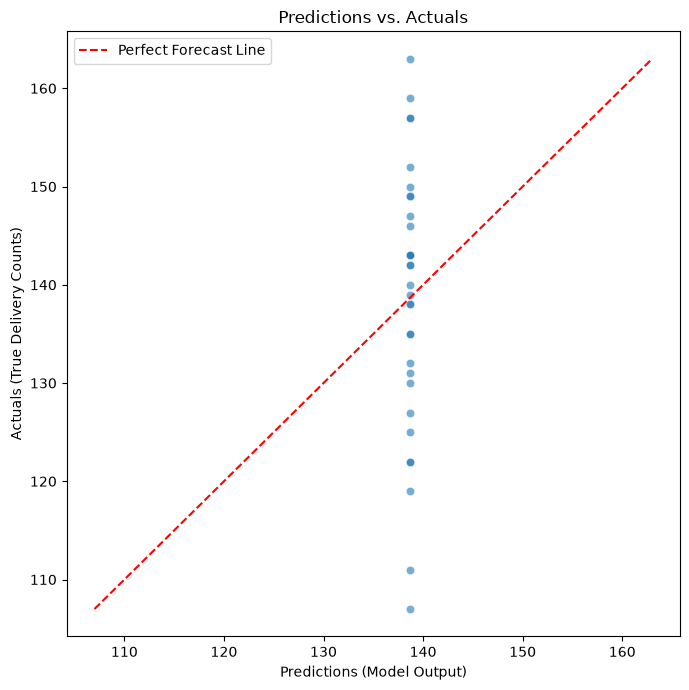

In [17]:
# Plot predictions against actual values.
plt.figure(figsize=(7, 7))

# Create the scatter plot.
sns.scatterplot(x=ma_predictions, y=y_test, alpha=0.6)

# Label the axes.
plt.xlabel("Predictions (Model Output)")
plt.ylabel("Actuals (True Delivery Counts)")
plt.title("Predictions vs. Actuals")

# Add a perfect-forecast reference line.

min_val = min(y_test.min(), ma_predictions.min())
max_val = max(y_test.max(), ma_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Forecast Line')

plt.legend()
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

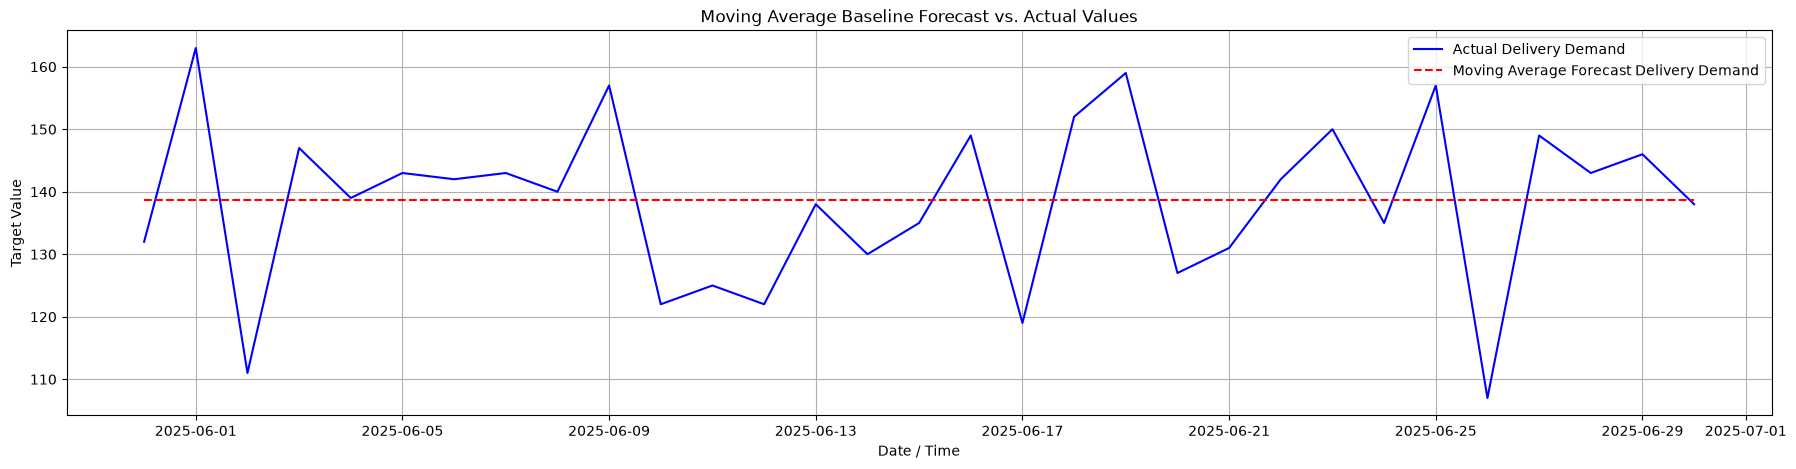

In [18]:
plt.figure(figsize=(22, 5))

# Plot actual and forecast values.
plt.plot(y_test.index, y_test, label='Actual Delivery Demand', color='blue')
plt.plot(y_test.index, ma_predictions, label='Moving Average Forecast Delivery Demand', color='red', linestyle='--')

# Add labels, a grid, and a legend.
plt.title('Moving Average Baseline Forecast vs. Actual Values')
plt.xlabel('Date / Time')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)

plt.show

## 5. ARIMA Forecast

ARIMA uses only past delivery counts to forecast the test period.

In [19]:
# Fit an ARIMA(1, 1, 4) model.

arima_model = ARIMA(y_train, order=(1,1,4)) 
fitted_arima_model = arima_model.fit() 
 
arima_predictions = fitted_arima_model.forecast(steps=len(y_test))

In [20]:
# Evaluate the forecast.
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_predictions))
arima_mae = mean_absolute_error(y_test, arima_predictions)
arima_mape = np.mean(np.abs((y_test - arima_predictions) / y_test)) * 100
arima_mfe = np.mean(y_test - arima_predictions)

print(f"MAE:  {arima_mae:.2f}")
print(f"RMSE: {arima_rmse:.2f}")
print(f"MAPE: {arima_mape:.2f}%")
print(f"Bias (MFE): {arima_mfe:.2f}")

MAE:  10.57
RMSE: 13.18
MAPE: 7.88%
Bias (MFE): 0.48


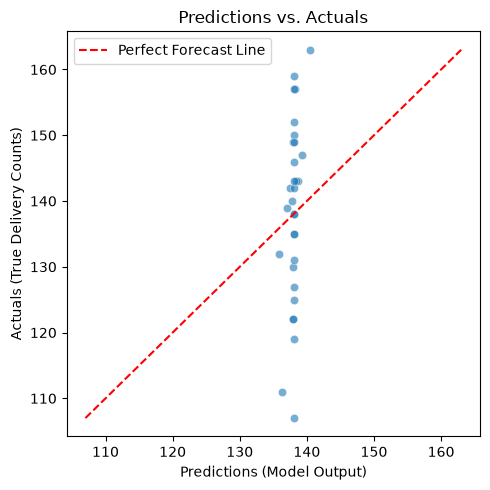

In [21]:
# Plot predictions against actual values.
plt.figure(figsize=(5, 5))

# Create the scatter plot.
sns.scatterplot(x=arima_predictions, y=y_test, alpha=0.6)

# Label the axes.
plt.xlabel("Predictions (Model Output)")
plt.ylabel("Actuals (True Delivery Counts)")
plt.title("Predictions vs. Actuals")

# Add a perfect-forecast reference line.

min_val = min(y_test.min(), arima_predictions.min())
max_val = max(y_test.max(), arima_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Forecast Line')

plt.legend()
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

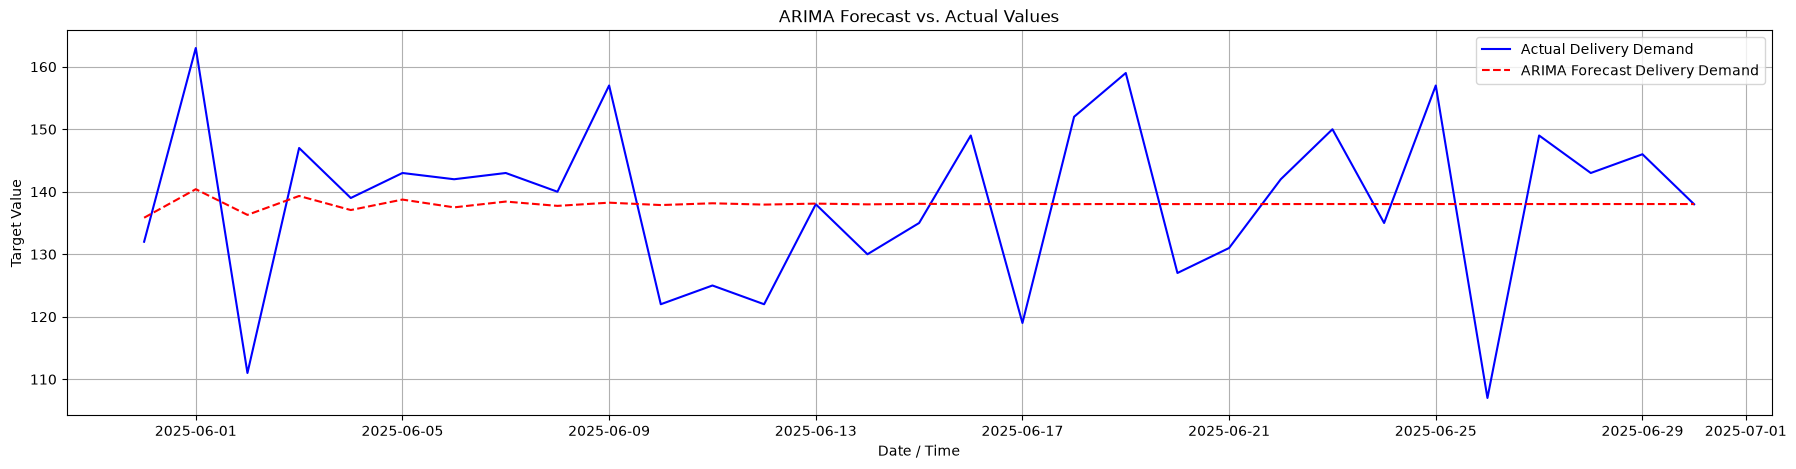

In [22]:
plt.figure(figsize=(22, 5))

# Plot actual and forecast values.
plt.plot(y_test.index, y_test, label='Actual Delivery Demand', color='blue')
plt.plot(y_test.index, arima_predictions, label='ARIMA Forecast Delivery Demand', color='red', linestyle='--')

# Add labels, a grid, and a legend.
plt.title('ARIMA Forecast vs. Actual Values')
plt.xlabel('Date / Time')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)

plt.show

## 6. Regression Models

Linear regression and random forest use the available delivery features to predict daily demand.

In [24]:
# Fit the linear regression model.
lm = LinearRegression()
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.94, 1.01, 0.51,...,-14.01, 0.13, -0.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['unfavorable_weather_count','extreme_temp_count','distance_km_mean',..., 'expected_delivery_duration_hrs','day_of_week','is_weekend']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.57
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [25]:
lm_predictions = lm.predict(X_test)

In [26]:
# Evaluate the forecast.
lm_rmse = np.sqrt(mean_squared_error(y_test, lm_predictions))
lm_mae = mean_absolute_error(y_test, lm_predictions)
lm_mape = np.mean(np.abs((y_test - lm_predictions) / y_test)) * 100
lm_mfe = np.mean(y_test - lm_predictions)

print(f"MAE:  {lm_mae:.2f}")
print(f"RMSE: {lm_rmse:.2f}")
print(f"MAPE: {lm_mape:.2f}%")
print(f"Bias (MFE): {lm_mfe:.2f}")

MAE:  4.13
RMSE: 5.31
MAPE: 2.99%
Bias (MFE): 1.67


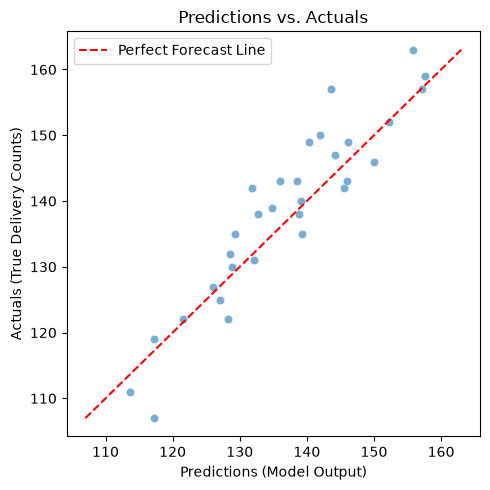

In [27]:
# Plot predictions against actual values.
plt.figure(figsize=(5, 5))

# Create the scatter plot.
sns.scatterplot(x=lm_predictions, y=y_test, alpha=0.6)

# Label the axes.
plt.xlabel("Predictions (Model Output)")
plt.ylabel("Actuals (True Delivery Counts)")
plt.title("Predictions vs. Actuals")

# Add a perfect-forecast reference line.

min_val = min(y_test.min(), lm_predictions.min())
max_val = max(y_test.max(), lm_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Forecast Line')

plt.legend()
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

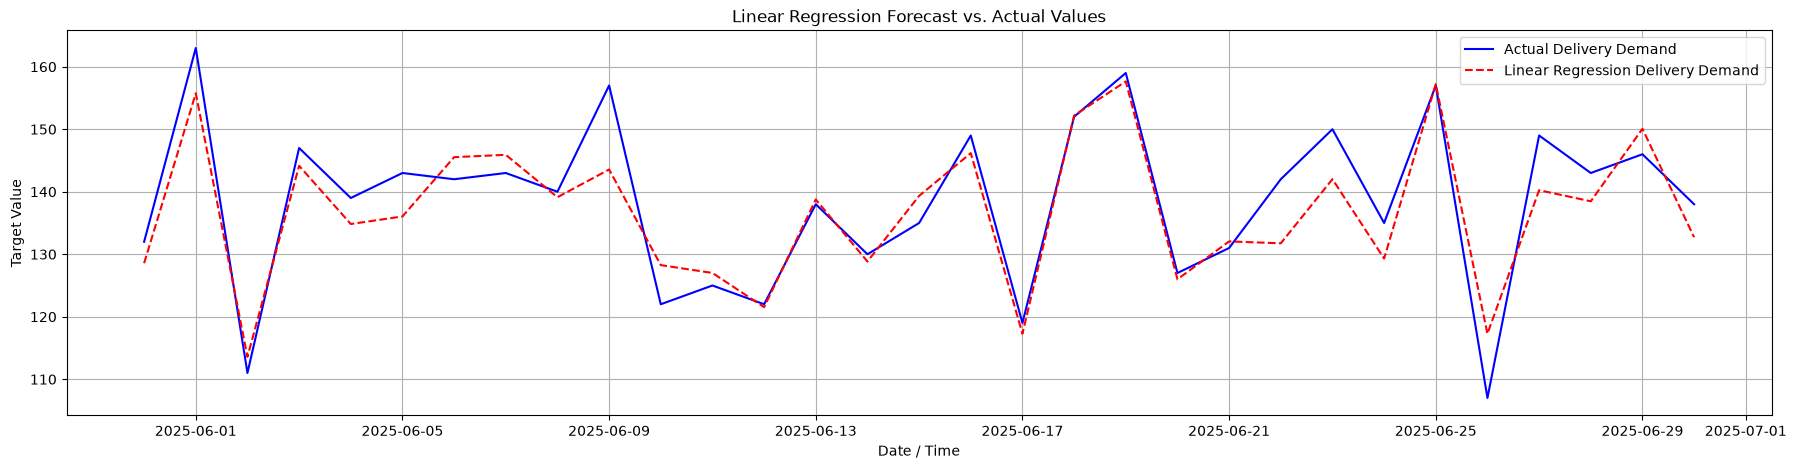

In [28]:
plt.figure(figsize=(22, 5))

# Plot actual and forecast values.
plt.plot(y_test.index, y_test, label='Actual Delivery Demand', color='blue')
plt.plot(y_test.index, lm_predictions, label='Linear Regression Delivery Demand', color='red', linestyle='--')

# Add labels, a grid, and a legend.
plt.title('Linear Regression Forecast vs. Actual Values')
plt.xlabel('Date / Time')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)

plt.show

In [29]:
# Fit the random forest model.
rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=5,           
    min_samples_leaf=1,    
    random_state=42
)

rf.fit(X_train, y_train) 
rf_predictions = rf.predict(X_test) 

In [30]:
# Evaluate the forecast.
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mape = np.mean(np.abs((y_test - rf_predictions) / y_test)) * 100
rf_mfe = np.mean(y_test - rf_predictions)

print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAPE: {rf_mape:.2f}%")
print(f"Bias (MFE): {rf_mfe:.2f}")

MAE:  5.08
RMSE: 6.72
MAPE: 3.70%
Bias (MFE): 1.23


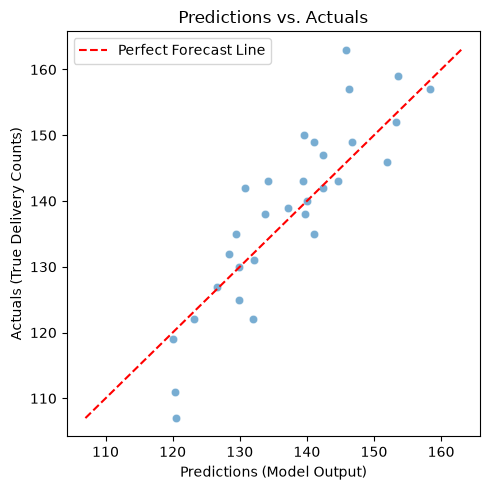

In [31]:
# Plot predictions against actual values.
plt.figure(figsize=(5, 5))

# Create the scatter plot.
sns.scatterplot(x=rf_predictions, y=y_test, alpha=0.6)

# Label the axes.
plt.xlabel("Predictions (Model Output)")
plt.ylabel("Actuals (True Delivery Counts)")
plt.title("Predictions vs. Actuals")

# Add a perfect-forecast reference line.

min_val = min(y_test.min(), rf_predictions.min())
max_val = max(y_test.max(), rf_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Forecast Line')

plt.legend()
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

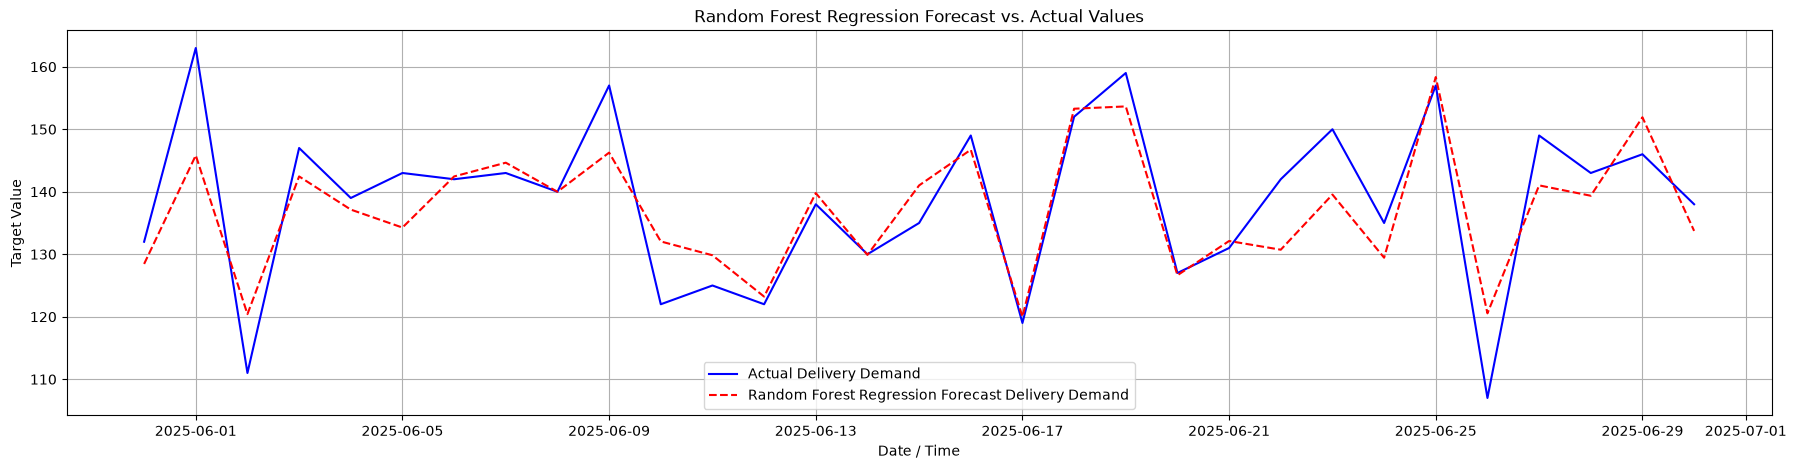

In [32]:
plt.figure(figsize=(22, 5))

# Plot actual and forecast values.
plt.plot(y_test.index, y_test, label='Actual Delivery Demand', color='blue')
plt.plot(y_test.index, rf_predictions, label='Random Forest Regression Forecast Delivery Demand', color='red', linestyle='--')

# Add labels, a grid, and a legend.
plt.title('Random Forest Regression Forecast vs. Actual Values')
plt.xlabel('Date / Time')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)

plt.show

## 7. Prophet Forecast

Prophet combines time-series patterns with the available delivery features.

In [33]:
# Prepare the data and fit the Prophet model.
prophet_train = y_train.reset_index()
prophet_train.rename(columns={'delivery_date' : 'ds', 'delivery_count' : 'y'}, inplace=True)

regressor_columns = X_train.columns
prophet_train = pd.merge(prophet_train, X_train[regressor_columns], how="inner", left_on="ds", right_index=True)

# Configure the model.
prophet_model = Prophet(
    yearly_seasonality=False,   
    weekly_seasonality=True,    
    daily_seasonality=False     
)

for col in regressor_columns:
    prophet_model.add_regressor(col)
    
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(y_test), freq='D')

for col in regressor_columns:
    concatenated_data = pd.concat([X_train[col], X_test[col]], axis=0)
    future[col] = concatenated_data.values

forecast = prophet_model.predict(future)
prophet_predictions = forecast['yhat'].iloc[-len(y_test):].values

17:15:39 - cmdstanpy - INFO - Chain [1] start processing
17:15:39 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
# Evaluate the forecast.
prophet_rmse = np.sqrt(mean_squared_error(y_test, prophet_predictions))
prophet_mae = mean_absolute_error(y_test, prophet_predictions)
prophet_mape = np.mean(np.abs((y_test - prophet_predictions) / y_test)) * 100
prophet_mfe = np.mean(y_test - prophet_predictions)

print(f"MAE:  {prophet_mae:.2f}")
print(f"RMSE: {prophet_rmse:.2f}")
print(f"MAPE: {prophet_mape:.2f}%")
print(f"Bias (MFE): {prophet_mfe:.2f}")

MAE:  4.60
RMSE: 5.70
MAPE: 3.30%
Bias (MFE): 2.88


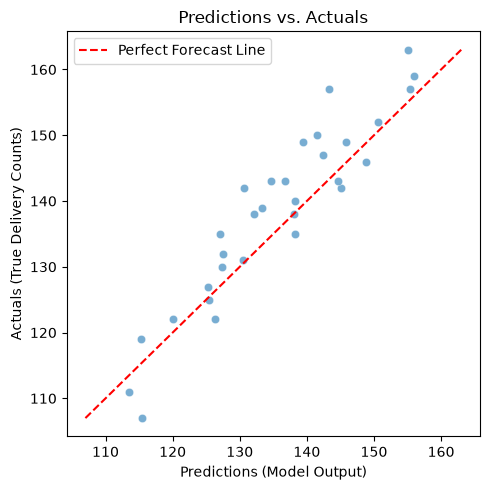

In [35]:
# Plot predictions against actual values.
plt.figure(figsize=(5, 5))

# Create the scatter plot.
sns.scatterplot(x=prophet_predictions, y=y_test, alpha=0.6)

# Label the axes.
plt.xlabel("Predictions (Model Output)")
plt.ylabel("Actuals (True Delivery Counts)")
plt.title("Predictions vs. Actuals")

# Add a perfect-forecast reference line.

min_val = min(y_test.min(), prophet_predictions.min())
max_val = max(y_test.max(), prophet_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Forecast Line')

plt.legend()
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

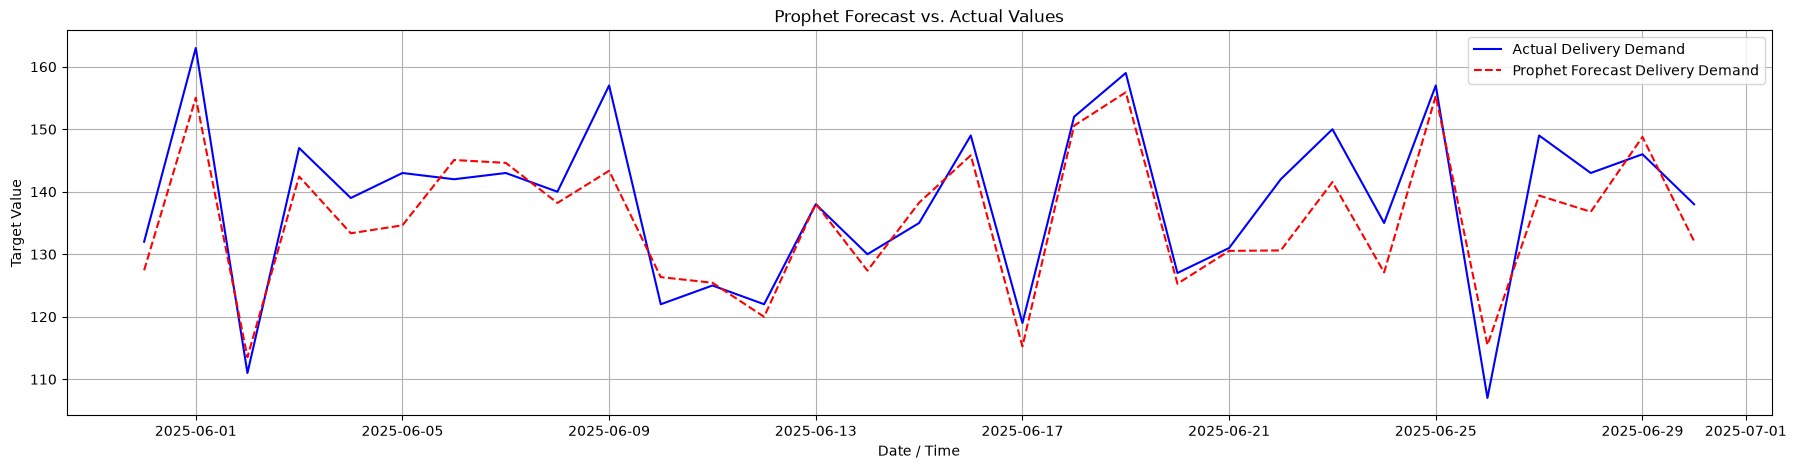

In [36]:
plt.figure(figsize=(22, 5))

# Plot actual and forecast values.
plt.plot(y_test.index, y_test, label='Actual Delivery Demand', color='blue')
plt.plot(y_test.index, prophet_predictions, label='Prophet Forecast Delivery Demand', color='red', linestyle='--')

# Add labels, a grid, and a legend.
plt.title('Prophet Forecast vs. Actual Values')
plt.xlabel('Date / Time')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)

plt.show